In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal

print("HRV feature extraction environment ready")

HRV feature extraction environment ready


In [2]:
rr_input_path = "../data/processed/rr_intervals"
feature_output_path = "../data/processed/features"

os.makedirs(feature_output_path, exist_ok=True)

print("RR input:", rr_input_path)
print("Feature output:", feature_output_path)

RR input: ../data/processed/rr_intervals
Feature output: ../data/processed/features


In [3]:
cleaned_files = sorted([
    f for f in os.listdir(rr_input_path)
    if f.endswith("_rr_cleaned.csv")
])

print("Cleaned RR files:", len(cleaned_files))
print(cleaned_files[:5])

Cleaned RR files: 44
['chf01_rr_cleaned.csv', 'chf02_rr_cleaned.csv', 'chf03_rr_cleaned.csv', 'chf04_rr_cleaned.csv', 'chf05_rr_cleaned.csv']


In [4]:
patient_id = "chf201"

rr_file = f"{rr_input_path}/{patient_id}_rr_cleaned.csv"

rr_df = pd.read_csv(rr_file)

rr_ms = rr_df["rr_ms"].values

print("Patient:", patient_id)
print("RR intervals:", len(rr_ms))
print("Mean RR:", np.mean(rr_ms))
print("Median RR:", np.median(rr_ms))

Patient: chf201
RR intervals: 112186
Mean RR: 738.1636300429643
Median RR: 734.375


In [5]:
window_duration_ms = 5 * 60 * 1000

cumulative_time = np.cumsum(rr_ms)

window_ids = (
    cumulative_time // window_duration_ms
).astype(int)

print("Number of windows:", window_ids.max() + 1)

Number of windows: 277


In [6]:
window_counts = pd.Series(window_ids).value_counts().sort_index()

print(window_counts)

0      390
1      459
2      447
3      381
4      368
      ... 
272    429
273    454
274    421
275    432
276     16
Name: count, Length: 277, dtype: int64


In [7]:
print("Minimum RR per window:", window_counts.min())
print("Maximum RR per window:", window_counts.max())

Minimum RR per window: 16
Maximum RR per window: 508


In [8]:
def calculate_time_domain_hrv(rr_ms):
    
    rr_ms = np.asarray(rr_ms)
    
    mean_rr = np.mean(rr_ms)
    
    sdnn = np.std(rr_ms, ddof=1)
    
    rmssd = np.sqrt(
        np.mean(
            np.diff(rr_ms) ** 2
        )
    )
    
    diff_rr = np.abs(np.diff(rr_ms))
    
    pnn50 = (
        np.sum(diff_rr > 50)
        / len(diff_rr)
        * 100
    )
    
    return {
        "mean_rr": mean_rr,
        "sdnn": sdnn,
        "rmssd": rmssd,
        "pnn50": pnn50
    }

In [9]:
test_features = calculate_time_domain_hrv(rr_ms)

test_features

{'mean_rr': np.float64(738.1636300429643),
 'sdnn': np.float64(76.19777114309836),
 'rmssd': np.float64(25.26055827841948),
 'pnn50': np.float64(2.1892409858715514)}

In [10]:
window_0_rr = rr_ms[window_ids == 0]

print("Window 0 RR count:", len(window_0_rr))

features_0 = calculate_time_domain_hrv(window_0_rr)

features_0

Window 0 RR count: 390


{'mean_rr': np.float64(767.2676282051282),
 'sdnn': np.float64(67.91488278697165),
 'rmssd': np.float64(25.53600761216674),
 'pnn50': np.float64(3.5989717223650386)}

In [11]:
def calculate_frequency_domain_hrv(rr_ms):
    
    rr_ms = np.asarray(rr_ms, dtype=float)
    
    # Convert RR intervals to cumulative time in seconds
    rr_sec = rr_ms / 1000.0
    time_sec = np.cumsum(rr_sec)
    
    # Remove first point so time and RR values align
    time_sec = time_sec - time_sec[0]
    
    # Uniform sampling frequency
    fs = 4.0
    
    # Uniform time grid
    uniform_time = np.arange(
        time_sec[0],
        time_sec[-1],
        1 / fs
    )
    
    # Interpolate RR series
    rr_interp = np.interp(
        uniform_time,
        time_sec,
        rr_ms
    )
    
    # Detrend
    rr_interp = signal.detrend(rr_interp)
    
    # Welch power spectral density
    frequencies, psd = signal.welch(
        rr_interp,
        fs=fs,
        nperseg=min(256, len(rr_interp))
    )
    
    # Frequency bands
    lf_mask = (frequencies >= 0.04) & (frequencies < 0.15)
    hf_mask = (frequencies >= 0.15) & (frequencies < 0.40)
    
    # Integrate PSD within each band
    lf_power = np.trapezoid(
        psd[lf_mask],
        frequencies[lf_mask]
    )
    
    hf_power = np.trapezoid(
        psd[hf_mask],
        frequencies[hf_mask]
    )
    
    # LF/HF ratio
    if hf_power > 0:
        lf_hf = lf_power / hf_power
    else:
        lf_hf = np.nan
    
    return {
        "lf_power": lf_power,
        "hf_power": hf_power,
        "lf_hf": lf_hf
    }

In [12]:
frequency_features_0 = calculate_frequency_domain_hrv(
    window_0_rr
)

frequency_features_0

{'lf_power': np.float64(529.8630187943825),
 'hf_power': np.float64(206.52710817124398),
 'lf_hf': np.float64(2.5655858133405003)}

In [13]:
def plot_hrv_psd(rr_ms):
    
    rr_ms = np.asarray(rr_ms, dtype=float)
    
    rr_sec = rr_ms / 1000.0
    time_sec = np.cumsum(rr_sec)
    time_sec = time_sec - time_sec[0]
    
    fs = 4.0
    
    uniform_time = np.arange(
        time_sec[0],
        time_sec[-1],
        1 / fs
    )
    
    rr_interp = np.interp(
        uniform_time,
        time_sec,
        rr_ms
    )
    
    rr_interp = signal.detrend(rr_interp)
    
    frequencies, psd = signal.welch(
        rr_interp,
        fs=fs,
        nperseg=min(256, len(rr_interp))
    )
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(frequencies, psd)
    
    plt.xlim(0, 0.5)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title("HRV Power Spectral Density")
    
    plt.axvline(0.04, linestyle="--")
    plt.axvline(0.15, linestyle="--")
    plt.axvline(0.40, linestyle="--")
    
    plt.show()

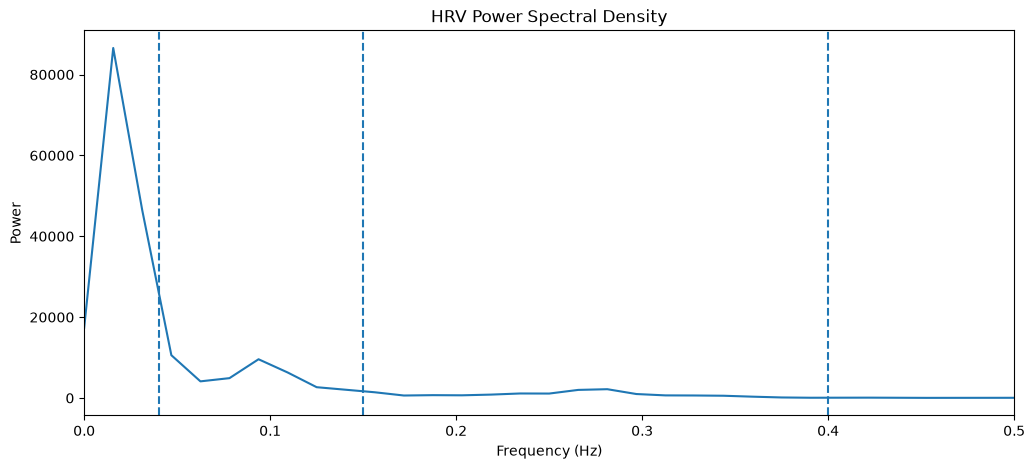

In [14]:
plot_hrv_psd(window_0_rr)

In [15]:
def calculate_hrv_features(rr_ms):
    
    time_features = calculate_time_domain_hrv(rr_ms)
    
    frequency_features = calculate_frequency_domain_hrv(rr_ms)
    
    return {
        **time_features,
        **frequency_features
    }

In [16]:
all_features_0 = calculate_hrv_features(window_0_rr)

all_features_0

{'mean_rr': np.float64(767.2676282051282),
 'sdnn': np.float64(67.91488278697165),
 'rmssd': np.float64(25.53600761216674),
 'pnn50': np.float64(3.5989717223650386),
 'lf_power': np.float64(529.8630187943825),
 'hf_power': np.float64(206.52710817124398),
 'lf_hf': np.float64(2.5655858133405003)}

In [17]:
frequency_features_0

{'lf_power': np.float64(529.8630187943825),
 'hf_power': np.float64(206.52710817124398),
 'lf_hf': np.float64(2.5655858133405003)}

In [18]:
all_features_0

{'mean_rr': np.float64(767.2676282051282),
 'sdnn': np.float64(67.91488278697165),
 'rmssd': np.float64(25.53600761216674),
 'pnn50': np.float64(3.5989717223650386),
 'lf_power': np.float64(529.8630187943825),
 'hf_power': np.float64(206.52710817124398),
 'lf_hf': np.float64(2.5655858133405003)}

In [19]:
def calculate_window_features(rr_ms, window_duration_ms=5 * 60 * 1000):
    
    rr_ms = np.asarray(rr_ms, dtype=float)
    
    # Cumulative elapsed time
    rr_sec = rr_ms / 1000.0
    cumulative_time = np.cumsum(rr_sec) * 1000
    
    # Assign each RR interval to a 5-minute window
    window_ids = (
        cumulative_time // window_duration_ms
    ).astype(int)
    
    records = []
    
    for window_id in np.unique(window_ids):
        
        window_rr = rr_ms[window_ids == window_id]
        
        # Skip very small windows
        if len(window_rr) < 30:
            continue
        
        features = calculate_hrv_features(window_rr)
        
        features["window_id"] = int(window_id)
        features["rr_count"] = len(window_rr)
        
        records.append(features)
    
    return pd.DataFrame(records)

In [20]:
chf201_features = calculate_window_features(rr_ms)

print("Number of valid windows:", len(chf201_features))

chf201_features.head()

Number of valid windows: 276


,mean_rr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf,window_id,rr_count
0,767.267628,67.914883,25.536008,3.598972,529.863019,206.527108,2.565586,0,390
1,654.735158,61.645253,19.416626,0.436681,219.663553,60.316968,3.641820,1,459
2,671.280761,74.198385,28.034448,4.932735,524.664811,125.706820,4.173718,2,447
3,786.294291,76.440690,30.558761,8.684211,1102.536873,221.347788,4.981016,3,381
4,815.981658,69.947196,28.118140,7.084469,655.548991,184.260187,3.557735,4,368


In [21]:
chf201_features.insert(
    0,
    "patient_id",
    patient_id
)

chf201_features.head()

,patient_id,mean_rr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf,window_id,rr_count
0,chf201,767.267628,67.914883,25.536008,3.598972,529.863019,206.527108,2.565586,0,390
1,chf201,654.735158,61.645253,19.416626,0.436681,219.663553,60.316968,3.641820,1,459
2,chf201,671.280761,74.198385,28.034448,4.932735,524.664811,125.706820,4.173718,2,447
3,chf201,786.294291,76.440690,30.558761,8.684211,1102.536873,221.347788,4.981016,3,381
4,chf201,815.981658,69.947196,28.118140,7.084469,655.548991,184.260187,3.557735,4,368


In [22]:
def calculate_trend_features(feature_df):
    
    df = feature_df.copy()
    
    x = df["window_id"].values
    
    trend_features = {}
    
    for feature in ["sdnn", "rmssd", "pnn50"]:
        
        y = df[feature].values
        
        # Need at least two valid points
        if len(y) >= 2:
            slope = np.polyfit(x, y, 1)[0]
        else:
            slope = np.nan
        
        trend_features[f"{feature}_trend"] = slope
    
    return trend_features

In [23]:
trend_0 = calculate_trend_features(chf201_features)

trend_0

{'sdnn_trend': np.float64(-0.016271730801398033),
 'rmssd_trend': np.float64(-0.012841701063278279),
 'pnn50_trend': np.float64(0.002852183420117373)}

In [24]:
for feature_name, value in trend_0.items():
    chf201_features[feature_name] = value

In [25]:
chf201_features.head()

,patient_id,mean_rr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf,window_id,rr_count,sdnn_trend,rmssd_trend,pnn50_trend
0,chf201,767.267628,67.914883,25.536008,3.598972,529.863019,206.527108,2.565586,0,390,-0.016272,-0.012842,0.002852
1,chf201,654.735158,61.645253,19.416626,0.436681,219.663553,60.316968,3.641820,1,459,-0.016272,-0.012842,0.002852
2,chf201,671.280761,74.198385,28.034448,4.932735,524.664811,125.706820,4.173718,2,447,-0.016272,-0.012842,0.002852
3,chf201,786.294291,76.440690,30.558761,8.684211,1102.536873,221.347788,4.981016,3,381,-0.016272,-0.012842,0.002852
4,chf201,815.981658,69.947196,28.118140,7.084469,655.548991,184.260187,3.557735,4,368,-0.016272,-0.012842,0.002852


In [26]:
print("Shape:", chf201_features.shape)

print("\nColumns:")
print(chf201_features.columns.tolist())

print("\nMissing values:")
print(chf201_features.isna().sum())

Shape: (276, 13)

Columns:
['patient_id', 'mean_rr', 'sdnn', 'rmssd', 'pnn50', 'lf_power', 'hf_power', 'lf_hf', 'window_id', 'rr_count', 'sdnn_trend', 'rmssd_trend', 'pnn50_trend']

Missing values:
patient_id     0
mean_rr        0
sdnn           0
rmssd          0
pnn50          0
lf_power       0
hf_power       0
lf_hf          0
window_id      0
rr_count       0
sdnn_trend     0
rmssd_trend    0
pnn50_trend    0
dtype: int64


In [27]:
chf201_features.to_csv(
    f"{feature_output_path}/chf201_hrv_features.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [28]:
print(
    os.path.exists(
        f"{feature_output_path}/chf201_hrv_features.csv"
    )
)

True


In [29]:
print(chf201_features.shape)

(276, 13)


In [30]:
chf201_features

,patient_id,mean_rr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf,window_id,rr_count,sdnn_trend,rmssd_trend,pnn50_trend
0,chf201,767.267628,67.914883,25.536008,3.598972,529.863019,206.527108,2.565586,0,390,-0.016272,-0.012842,0.002852
1,chf201,654.735158,61.645253,19.416626,0.436681,219.663553,60.316968,3.641820,1,459,-0.016272,-0.012842,0.002852
2,chf201,671.280761,74.198385,28.034448,4.932735,524.664811,125.706820,4.173718,2,447,-0.016272,-0.012842,0.002852
3,chf201,786.294291,76.440690,30.558761,8.684211,1102.536873,221.347788,4.981016,3,381,-0.016272,-0.012842,0.002852
4,chf201,815.981658,69.947196,28.118140,7.084469,655.548991,184.260187,3.557735,4,368,-0.016272,-0.012842,0.002852
...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,chf201,741.781405,44.545597,17.092423,0.496278,457.159914,62.663270,7.295500,271,404,-0.016272,-0.012842,0.002852
272,chf201,699.828817,27.028056,16.088163,0.233645,200.521110,56.903797,3.523862,272,429,-0.016272,-0.012842,0.002852
273,chf201,660.741327,28.192165,11.995727,0.220751,142.410723,20.515267,6.941695,273,454,-0.016272,-0.012842,0.002852
274,chf201,712.236490,39.322721,14.460915,0.476190,275.288437,40.955750,6.721606,274,421,-0.016272,-0.012842,0.002852


In [31]:
chf201_features.head()
chf201_features.isna().sum()

patient_id     0
mean_rr        0
sdnn           0
rmssd          0
pnn50          0
lf_power       0
hf_power       0
lf_hf          0
window_id      0
rr_count       0
sdnn_trend     0
rmssd_trend    0
pnn50_trend    0
dtype: int64

In [33]:
def process_patient_hrv(patient_id):
    
    rr_file = f"{rr_input_path}/{patient_id}_rr_cleaned.csv"
    
    # Load cleaned RR intervals
    rr_df = pd.read_csv(rr_file)
    rr_ms = rr_df["rr_ms"].values
    
    # Calculate window-level HRV features
    features = calculate_window_features(rr_ms)
    
    # Add patient ID
    features.insert(0, "patient_id", patient_id)
    
    # Calculate patient-level temporal trends
    trends = calculate_trend_features(features)
    
    # Add trends to every window
    for feature_name, value in trends.items():
        features[feature_name] = value
    
    return features

In [34]:
test_features = process_patient_hrv("chf201")

print("Shape:", test_features.shape)
print(test_features.head())

Shape: (276, 13)
  patient_id     mean_rr       sdnn      rmssd     pnn50     lf_power  \
0     chf201  767.267628  67.914883  25.536008  3.598972   529.863019   
1     chf201  654.735158  61.645253  19.416626  0.436681   219.663553   
2     chf201  671.280761  74.198385  28.034448  4.932735   524.664811   
3     chf201  786.294291  76.440690  30.558761  8.684211  1102.536873   
4     chf201  815.981658  69.947196  28.118140  7.084469   655.548991   

     hf_power     lf_hf  window_id  rr_count  sdnn_trend  rmssd_trend  \
0  206.527108  2.565586          0       390   -0.016272    -0.012842   
1   60.316968  3.641820          1       459   -0.016272    -0.012842   
2  125.706820  4.173718          2       447   -0.016272    -0.012842   
3  221.347788  4.981016          3       381   -0.016272    -0.012842   
4  184.260187  3.557735          4       368   -0.016272    -0.012842   

   pnn50_trend  
0     0.002852  
1     0.002852  
2     0.002852  
3     0.002852  
4     0.002852  


In [35]:
all_feature_tables = []

for i, filename in enumerate(cleaned_files, start=1):
    
    patient_id = filename.replace("_rr_cleaned.csv", "")
    
    print(f"[{i}/44] Processing {patient_id}...")
    
    patient_features = process_patient_hrv(patient_id)
    
    all_feature_tables.append(patient_features)

print("Finished processing all patients.")

[1/44] Processing chf01...
[2/44] Processing chf02...
[3/44] Processing chf03...
[4/44] Processing chf04...
[5/44] Processing chf05...
[6/44] Processing chf06...
[7/44] Processing chf07...
[8/44] Processing chf08...
[9/44] Processing chf09...
[10/44] Processing chf10...
[11/44] Processing chf11...
[12/44] Processing chf12...
[13/44] Processing chf13...
[14/44] Processing chf14...
[15/44] Processing chf15...
[16/44] Processing chf201...
[17/44] Processing chf202...
[18/44] Processing chf203...
[19/44] Processing chf204...
[20/44] Processing chf205...
[21/44] Processing chf206...
[22/44] Processing chf207...
[23/44] Processing chf208...
[24/44] Processing chf209...
[25/44] Processing chf210...
[26/44] Processing chf211...
[27/44] Processing chf212...
[28/44] Processing chf213...
[29/44] Processing chf214...
[30/44] Processing chf215...
[31/44] Processing chf216...
[32/44] Processing chf217...
[33/44] Processing chf218...
[34/44] Processing chf219...
[35/44] Processing chf220...
[36/44] P

In [36]:
hrv_features = pd.concat(
    all_feature_tables,
    ignore_index=True
)

print("Final shape:", hrv_features.shape)

Final shape: (11109, 13)


In [37]:
print(
    "Number of patients:",
    hrv_features["patient_id"].nunique()
)

print(
    "Number of windows:",
    len(hrv_features)
)

Number of patients: 44
Number of windows: 11109


In [38]:
windows_per_patient = (
    hrv_features
    .groupby("patient_id")
    .size()
    .sort_values()
)

print(windows_per_patient)

patient_id
chf212    196
chf214    203
chf225    215
chf209    226
chf207    227
chf02     230
chf06     237
chf05     238
chf12     238
chf09     238
chf10     239
chf03     240
chf08     240
chf07     240
chf04     240
chf11     240
chf14     240
chf15     240
chf13     240
chf01     240
chf204    247
chf202    247
chf203    249
chf206    251
chf218    254
chf205    261
chf216    263
chf222    264
chf219    264
chf223    272
chf221    272
chf210    273
chf229    273
chf226    273
chf228    273
chf227    274
chf215    274
chf201    276
chf217    279
chf220    280
chf213    284
chf211    285
chf224    286
chf208    288
dtype: int64


In [39]:
print("\nMinimum windows:", windows_per_patient.min())
print("Maximum windows:", windows_per_patient.max())
print("Mean windows:", windows_per_patient.mean())
print("Median windows:", windows_per_patient.median())


Minimum windows: 196
Maximum windows: 288
Mean windows: 252.47727272727272
Median windows: 248.0


In [40]:
print(
    hrv_features.isna().sum()
)

patient_id     0
mean_rr        0
sdnn           0
rmssd          0
pnn50          0
lf_power       0
hf_power       0
lf_hf          0
window_id      0
rr_count       0
sdnn_trend     0
rmssd_trend    0
pnn50_trend    0
dtype: int64


In [41]:
numeric_features = hrv_features.select_dtypes(
    include=np.number
)

print(
    "Infinite values:",
    np.isinf(numeric_features).sum().sum()
)

Infinite values: 0


In [42]:
hrv_features.describe()

,mean_rr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf,window_id,rr_count,sdnn_trend,rmssd_trend,pnn50_trend
count,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000,11109.000000
mean,693.809761,48.987809,59.627603,10.188912,488.706362,592.068838,1.143832,126.715276,444.755964,0.027112,0.029341,0.008866
std,123.095652,36.770998,53.167216,15.628539,1794.878963,1439.000402,1.804403,74.520809,75.871764,0.106419,0.181858,0.064135
min,429.117489,4.170726,3.875617,0.000000,0.466494,1.051363,0.014463,0.000000,32.000000,-0.120049,-0.234093,-0.119702
25%,599.718750,22.570545,21.395412,1.219512,22.963103,40.116684,0.243945,63.000000,390.000000,-0.032196,-0.051393,-0.009219
50%,672.996076,38.662841,39.759181,3.902439,77.794093,142.821431,0.520061,126.000000,445.000000,0.006304,0.004221,0.001550
75%,768.790064,64.880345,83.915609,11.278195,261.004309,558.059380,1.157771,189.000000,500.000000,0.077580,0.069247,0.017214
max,1173.614502,293.725844,340.317953,100.000000,49481.146625,34207.100299,23.966886,287.000000,699.000000,0.519238,0.927057,0.376120


In [43]:
hrv_output_file = (
    f"{feature_output_path}/hrv_features.csv"
)

hrv_features.to_csv(
    hrv_output_file,
    index=False
)

print("Saved:", hrv_output_file)

Saved: ../data/processed/features/hrv_features.csv


In [44]:
print(
    os.path.exists(hrv_output_file)
)

True


In [45]:
check_df = pd.read_csv(hrv_output_file)

print("Shape:", check_df.shape)
print("Patients:", check_df["patient_id"].nunique())
print("Missing values:", check_df.isna().sum().sum())

Shape: (11109, 13)
Patients: 44
Missing values: 0


In [46]:
print("Final shape:", hrv_features.shape)
print("Patients:", hrv_features["patient_id"].nunique())
print(hrv_features.isna().sum())
print(np.isinf(hrv_features.select_dtypes(include=np.number)).sum().sum())

Final shape: (11109, 13)
Patients: 44
patient_id     0
mean_rr        0
sdnn           0
rmssd          0
pnn50          0
lf_power       0
hf_power       0
lf_hf          0
window_id      0
rr_count       0
sdnn_trend     0
rmssd_trend    0
pnn50_trend    0
dtype: int64
0
